# v16 — Regime Labeling: di kondisi market apa v13 menang, dan di kondisi apa dia bahaya?

**Masalah yang diselesaikan:** angka agregat v13 (win rate 75% di TEST, 70.6% di full
2025-2026, 52.6%→74.0% per tahun di 2019-2026) itu RATA-RATA — bisa menyembunyikan bahwa
strategi cuma menang di SATU jenis kondisi market & rugi di kondisi lain. Analoginya: dokter
bilang "rata-rata suhu pasien 37°C" kedengaran normal, padahal separuh demam 40°C & separuh
hipotermia 34°C — rata-rata menutupi 2 kondisi ekstrem yang saling menetralkan.

**Regime labeling** memecah data berdasarkan KONDISI MARKET objektif (bukan rata-rata gabungan),
lalu hitung performa per kondisi terpisah:
- **Trend**: ADX≥25 → Trending, ADX<25 → Ranging (ADX sudah dipakai sbg hard filter di v13,
  `adx_min=18` — tapi itu cuma exclude ADX SANGAT rendah, belum membedakan trending KUAT vs
  trending LEMAH di atas 18)
- **Volatilitas**: ATR% (ATR/close*100) tinggi vs rendah, split di median tiap dataset (bukan
  angka absolut tetap, krn skala harga XAUUSD berubah drastis 2019→2026 — $1300 vs $4300+)

Hasilnya matriks 2x2 (Trending/Ranging × High Vol/Low Vol) + breakdown per kuartil ADX yang
lebih halus, dihitung di **3 dataset sekaligus** (TEST 196 trade, full 2025-2026 721 trade,
full 2019-2026 3056 trade) — konsisten dgn metodologi v14 (Monte Carlo), supaya temuan yang
konsisten di ketiga dataset lebih bisa dipercaya drpd cuma 1 dataset kebetulan.

**Kenapa penting:** data yang sudah ada (win rate 52.6% di 2019 vs 74.0% di 2026) itu HINT kuat
bahwa performa v13 bergantung pada kondisi market — regime labeling membuat itu EKSPLISIT &
terukur, bukan cuma dugaan dari tren tahunan. Dari sini bisa dicek apakah perlu filter tambahan
("robot cuma trading di regime yang historis profitable") — tapi v16 ini murni ANALISIS,
belum tentu berujung perubahan kode (tergantung temuannya).

**Bukan riset ubah parameter/strategi (untuk saat ini)** — v16 TIDAK mengubah sinyal, TP/SL,
atau filter apa pun dari v13. Isu ketiga dari 3 yang direncanakan untuk pematangan v13, setelah
Monte Carlo (v14) dan Deflated Sharpe Ratio (v15).

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

STRATEGY_NAME = "m5_scalping"
VERSION = "v16"

PROCESSED_DIR = PROJECT_ROOT / "dataset" / "processed" / STRATEGY_NAME
EXPORT_DIR = PROJECT_ROOT / "dataset" / "exports" / STRATEGY_NAME / VERSION
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

TREND_ADX_THRESHOLD = 25.0  # standar umum: ADX>=25 trending kuat, <25 lemah/ranging (Wilder)

pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (14, 5)

## 1. Load trade log dengan kolom ADX/ATR — TEST (196) & full 2025-2026 (721)

Kedua file ini sudah punya kolom `ind_adx`, `ind_atr` (indikator M5 saat entry, sama dgn yang
dipakai `_check_hard_filters`) dari backtest v13 sebelumnya -- tinggal dipakai langsung.

In [2]:
def prepare_regime_columns(df: pd.DataFrame, adx_col: str = "ind_adx", atr_col: str = "ind_atr", close_col: str = "ind_close") -> pd.DataFrame:
    """Tambah kolom regime (trend_regime, vol_regime, atr_pct) ke trade log yang sudah
    punya kolom ADX/ATR/close saat entry."""
    df = df.copy()
    df["adx_at_entry"] = df[adx_col]
    df["atr_pct_at_entry"] = df[atr_col] / df[close_col] * 100
    df["trend_regime"] = np.where(df["adx_at_entry"] >= TREND_ADX_THRESHOLD, "Trending", "Ranging")
    vol_median = df["atr_pct_at_entry"].median()
    df["vol_regime"] = np.where(df["atr_pct_at_entry"] >= vol_median, "High Vol", "Low Vol")
    df["regime_2x2"] = df["trend_regime"] + " / " + df["vol_regime"]
    return df


df_test = pd.read_csv(PROCESSED_DIR / "v13" / "trade_log_test_small_profit.csv")
df_test["entry_time"] = pd.to_datetime(df_test["entry_time"])
df_test = prepare_regime_columns(df_test)

df_full = pd.read_csv(PROCESSED_DIR / "v13" / "trade_log_full_final.csv")
df_full["entry_time"] = pd.to_datetime(df_full["entry_time"])
df_full = prepare_regime_columns(df_full)

print(f"TEST (196 trade): ADX median={df_test['adx_at_entry'].median():.1f}, ATR% median={df_test['atr_pct_at_entry'].median():.3f}")
print(f"Full 2025-2026 (721 trade): ADX median={df_full['adx_at_entry'].median():.1f}, ATR% median={df_full['atr_pct_at_entry'].median():.3f}")

TEST (196 trade): ADX median=27.0, ATR% median=0.119
Full 2025-2026 (721 trade): ADX median=26.5, ATR% median=0.094


## 2. Bangun trade log FULL 2019-2026 dengan kolom ADX/ATR (khusus regime labeling)

Trade log 2019-2026 yang sudah ada dari v14 (`trade_log_full_2019_2026_fixed_lot.csv`) cuma
punya `entry_time, direction, pnl, result` -- tidak menyimpan ADX/ATR/close saat entry yang
dibutuhkan utk regime labeling. Re-run backtest yang SAMA PERSIS (sinyal, SL/TP, filter identik
dgn v14 section 1b) tapi kali ini simpan kolom tambahan `adx_at_entry`, `atr_at_entry`,
`close_at_entry` per trade -- proses scoring 518K candle cukup cepat (~60 detik, sudah
dibuktikan di run v14 sebelumnya), jadi tidak masalah dihitung ulang drpd reuse cache yang gak
lengkap kolomnya.

In [3]:
FIXED_LOT = 0.01
CONTRACT_SIZE_1926 = 100.0
SPREAD_POINTS_1926 = 0.30
SL_MULT_1926, TP_MULT_1926 = 2.0, 4.0
MAX_HOLD_1926 = 12
SL_SMALL_1926, TP_SMALL_1926 = 1.25, 1.0
MAX_HOLD_SMALL_1926 = 6
ADX_MIN_1926 = 18.0
ATR_MIN_PCT_1926 = 0.03
MIN_SIGNAL_SCORE_1926 = 9.0

OSCILLATOR_CLUSTER_1926 = ["rsi", "stoch", "williams_r", "cci", "bb", "vwap"]
TREND_CLUSTER_1926 = ["sma", "ichimoku", "supertrend"]
OLD_WEIGHTS_1926 = {
    "rsi": 1.0, "stoch": 1.0, "williams_r": 1.0, "cci": 1.0, "bb": 1.0, "vwap": 1.5,
    "sma": 1.5, "ichimoku": 2.5, "supertrend": 2.5,
}
OSCILLATOR_WEIGHT_1926 = round(np.mean([1.0, 1.0, 1.0, 1.0, 1.0, 1.5]), 2)
TREND_WEIGHT_1926 = round(np.mean([1.5, 2.5, 2.5]), 2)


def check_h1_alignment_1926(row, direction):
    h1_ema_50 = row.get("h1_ema_50")
    h1_ema_200 = row.get("h1_ema_200")
    if h1_ema_50 is None or h1_ema_200 is None or pd.isna(h1_ema_50) or pd.isna(h1_ema_200):
        return True
    h1_trend = "UP" if h1_ema_50 > h1_ema_200 else ("DOWN" if h1_ema_50 < h1_ema_200 else "FLAT")
    if direction == "BUY" and h1_trend == "DOWN":
        return False
    if direction == "SELL" and h1_trend == "UP":
        return False
    return True


def has_opposing_ob_1926(row, direction):
    if direction == "BUY":
        return bool(row["ob_bear"] > 0 or row["h1_ob_bear"] > 0)
    return bool(row["ob_bull"] > 0 or row["h1_ob_bull"] > 0)


def build_direction_column_1926(df_signals):
    score = df_signals["v12_raw_score"]
    direction = pd.Series("WAIT", index=df_signals.index)
    direction[score >= MIN_SIGNAL_SCORE_1926] = "BUY"
    direction[score <= -MIN_SIGNAL_SCORE_1926] = "SELL"
    for idx in direction[direction != "WAIT"].index:
        row = df_signals.loc[idx]
        d = direction.loc[idx]
        if not check_h1_alignment_1926(row, d) or has_opposing_ob_1926(row, d):
            direction.loc[idx] = "WAIT"
    return direction


def run_backtest_with_regime_cols(df_signals: pd.DataFrame) -> pd.DataFrame:
    """Sama persis dgn run_backtest_fixed_lot_1926 di v14, TAPI simpan tambahan kolom
    adx_at_entry/atr_at_entry/close_at_entry per trade utk regime labeling."""
    df_signals = df_signals.copy()
    df_signals["signal_direction"] = build_direction_column_1926(df_signals)

    trades = []
    i = 0
    n = len(df_signals)

    while i < n:
        row = df_signals.iloc[i]
        direction = row["signal_direction"]
        if direction == "WAIT":
            i += 1
            continue

        dominant_chain = row["bull_chain"] if direction == "BUY" else row["bear_chain"]
        chain_maxed = dominant_chain >= 8
        cur_sl_mult, cur_tp_mult, cur_max_hold = SL_MULT_1926, TP_MULT_1926, MAX_HOLD_1926
        if chain_maxed:
            cur_sl_mult, cur_tp_mult, cur_max_hold = SL_SMALL_1926, TP_SMALL_1926, MAX_HOLD_SMALL_1926

        atr = row["atr"]
        if not np.isfinite(atr) or atr <= 0:
            i += 1
            continue

        sl_points = cur_sl_mult * atr
        tp_points = cur_tp_mult * atr
        entry_price = row["close"] + (SPREAD_POINTS_1926 if direction == "BUY" else -SPREAD_POINTS_1926)
        entry_time = row["datetime"]

        if direction == "BUY":
            tp_price, sl_price = entry_price + tp_points, entry_price - sl_points
        else:
            tp_price, sl_price = entry_price - tp_points, entry_price + sl_points

        exit_price = None
        exit_idx = min(i + cur_max_hold, n - 1)
        window_end = min(i + 1 + cur_max_hold, n)
        for candle_idx in range(i + 1, window_end):
            candle = df_signals.iloc[candle_idx]
            hit_tp = candle["high"] >= tp_price if direction == "BUY" else candle["low"] <= tp_price
            hit_sl = candle["low"] <= sl_price if direction == "BUY" else candle["high"] >= sl_price
            if hit_sl:
                exit_price, exit_time = sl_price, candle["datetime"]
                exit_idx = candle_idx
                break
            if hit_tp:
                exit_price, exit_time = tp_price, candle["datetime"]
                exit_idx = candle_idx
                break
        if exit_price is None:
            last_candle = df_signals.iloc[exit_idx]
            exit_price, exit_time = last_candle["close"], last_candle["datetime"]

        next_i = exit_idx + 1
        price_move = (exit_price - entry_price) if direction == "BUY" else (entry_price - exit_price)
        pnl = price_move * FIXED_LOT * CONTRACT_SIZE_1926
        trades.append({
            "entry_time": entry_time, "direction": direction, "pnl": pnl,
            "result": "WIN" if pnl > 0 else "LOSS",
            "adx_at_entry": float(row["adx"]),
            "atr_at_entry": float(atr),
            "close_at_entry": float(row["close"]),
        })
        i = next_i

    return pd.DataFrame(trades)


def score_de_redundant_1926(row: pd.Series) -> float:
    close = float(row["close"])
    atr = float(row.get("atr", close * 0.001))
    raw_scores = {
        "rsi": score_rsi(row)[0] / OLD_WEIGHTS_1926["rsi"],
        "stoch": score_stoch(row)[0] / OLD_WEIGHTS_1926["stoch"],
        "williams_r": score_williams_r(row)[0] / OLD_WEIGHTS_1926["williams_r"],
        "cci": score_cci(row)[0] / OLD_WEIGHTS_1926["cci"],
        "bb": score_bb(row, close)[0] / OLD_WEIGHTS_1926["bb"],
        "vwap": score_vwap(row, close)[0] / OLD_WEIGHTS_1926["vwap"],
        "sma": score_sma(row, close)[0] / OLD_WEIGHTS_1926["sma"],
        "ichimoku": score_ichimoku(row, close)[0] / OLD_WEIGHTS_1926["ichimoku"],
        "supertrend": score_supertrend(row)[0] / OLD_WEIGHTS_1926["supertrend"],
    }
    oscillator_raw = np.median([raw_scores[c] for c in OSCILLATOR_CLUSTER_1926])
    trend_raw = np.median([raw_scores[c] for c in TREND_CLUSTER_1926])
    components = {
        "oscillator_composite": oscillator_raw * OSCILLATOR_WEIGHT_1926,
        "trend_composite": trend_raw * TREND_WEIGHT_1926,
        "macd": score_macd(row)[0],
        "adx": score_adx(row)[0],
        "candle": score_candle(row)[0],
        "extra_patterns": score_extra_patterns(row)[0],
        "obv": score_obv(row)[0],
        "mfi": score_mfi(row)[0],
        "fibonacci": score_fibonacci(row, close, atr)[0],
        "rsi_divergence": score_rsi_divergence(row)[0],
        "momentum_chain": score_momentum_chain(row)[0],
        "psar": score_psar(row)[0],
        "smc": score_smc(row)[0],
    }
    return round(sum(components.values()), 3)

In [4]:
FULL_2019_2026_REGIME_PATH = PROCESSED_DIR / "v16" / "trade_log_full_2019_2026_with_regime.csv"
(PROCESSED_DIR / "v16").mkdir(parents=True, exist_ok=True)

if FULL_2019_2026_REGIME_PATH.exists():
    print(f"Sudah ada, load dari cache: {FULL_2019_2026_REGIME_PATH}")
    df_1926_trades = pd.read_csv(FULL_2019_2026_REGIME_PATH)
    df_1926_trades["entry_time"] = pd.to_datetime(df_1926_trades["entry_time"])
else:
    print("Belum ada cache -- generate dari awal (~518K candle, ~1-2 menit scoring)...")
    import time as _time

    from app.utils.signals.scoring import (
        score_adx, score_bb, score_candle, score_cci, score_extra_patterns,
        score_fibonacci, score_ichimoku, score_macd, score_mfi, score_momentum_chain,
        score_obv, score_psar, score_rsi, score_rsi_divergence, score_sma, score_smc,
        score_stoch, score_supertrend, score_vwap, score_williams_r,
    )

    df_m5_full = pd.read_csv(PROCESSED_DIR / "v01" / "xauusd_m5_full_indicators.csv")
    df_m5_full["datetime"] = pd.to_datetime(df_m5_full["datetime"])
    df_m5_full = df_m5_full.sort_values("datetime").reset_index(drop=True)

    df_h1_full = pd.read_csv(PROCESSED_DIR / "v01" / "xauusd_h1_full_indicators.csv")
    df_h1_full["datetime"] = pd.to_datetime(df_h1_full["datetime"])
    df_h1_full = df_h1_full.sort_values("datetime").reset_index(drop=True)

    df_h1_full_shifted = df_h1_full.copy()
    df_h1_full_shifted["h1_available_at"] = df_h1_full_shifted["datetime"] + pd.Timedelta(hours=1)
    h1_cols = [c for c in df_h1_full_shifted.columns if c != "h1_available_at"]
    df_h1_full_shifted = df_h1_full_shifted[["h1_available_at", *h1_cols]].rename(columns={c: f"h1_{c}" for c in h1_cols})

    df_1926 = pd.merge_asof(
        df_m5_full.sort_values("datetime"), df_h1_full_shifted.sort_values("h1_available_at"),
        left_on="datetime", right_on="h1_available_at", direction="backward",
    )
    print(f"FULL 2019-2026 dataset: {len(df_1926)} baris, {df_1926['datetime'].min()} -> {df_1926['datetime'].max()}")

    t0 = _time.time()
    scores = np.full(len(df_1926), np.nan)
    close_arr = df_1926["close"].to_numpy()
    adx_arr = df_1926["adx"].to_numpy()
    atr_arr = df_1926["atr"].to_numpy()

    for pos in range(len(df_1926)):
        if adx_arr[pos] < ADX_MIN_1926 or (close_arr[pos] > 0 and (atr_arr[pos] / close_arr[pos] * 100) < ATR_MIN_PCT_1926):
            continue
        row = df_1926.iloc[pos]
        scores[pos] = score_de_redundant_1926(row)
        if pos % 100_000 == 0:
            print(f"  scoring progress: {pos}/{len(df_1926)} ({_time.time()-t0:.0f}s elapsed)")

    df_1926["v12_raw_score"] = scores
    print(f"Scoring done in {_time.time()-t0:.0f}s. Non-null: {df_1926['v12_raw_score'].notna().sum()}")

    df_1926_trades = run_backtest_with_regime_cols(df_1926)
    df_1926_trades.to_csv(FULL_2019_2026_REGIME_PATH, index=False)
    print(f"Tersimpan ke cache: {FULL_2019_2026_REGIME_PATH}")

print(f"\nFull 2019-2026: {len(df_1926_trades)} trade, "
      f"{df_1926_trades['entry_time'].min()} -> {df_1926_trades['entry_time'].max()}")
print(f"  win_rate={100*(df_1926_trades['pnl']>0).mean():.2f}%  net_pnl=${df_1926_trades['pnl'].sum():.2f}")

# tambah kolom regime (pakai fungsi yg sama, tapi kolom sumbernya beda nama)
df_1926_trades["adx_at_entry"] = df_1926_trades["adx_at_entry"]
df_1926_trades["atr_pct_at_entry"] = df_1926_trades["atr_at_entry"] / df_1926_trades["close_at_entry"] * 100
df_1926_trades["trend_regime"] = np.where(df_1926_trades["adx_at_entry"] >= TREND_ADX_THRESHOLD, "Trending", "Ranging")
vol_median_1926 = df_1926_trades["atr_pct_at_entry"].median()
df_1926_trades["vol_regime"] = np.where(df_1926_trades["atr_pct_at_entry"] >= vol_median_1926, "High Vol", "Low Vol")
df_1926_trades["regime_2x2"] = df_1926_trades["trend_regime"] + " / " + df_1926_trades["vol_regime"]
print(f"\nADX median: {df_1926_trades['adx_at_entry'].median():.1f}, ATR% median: {vol_median_1926:.3f}")

Sudah ada, load dari cache: D:\Projects\robot-scalping\dataset\processed\m5_scalping\v16\trade_log_full_2019_2026_with_regime.csv

Full 2019-2026: 3056 trade, 2019-01-02 04:45:00+00:00 -> 2026-08-05 23:40:00+00:00
  win_rate=62.14%  net_pnl=$4914.50

ADX median: 26.3, ATR% median: 0.071


## 3. Fungsi analisis performa per regime

In [5]:
def regime_performance(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    """Hitung win rate, profit factor, net PnL, avg PnL, n trade per kategori regime."""
    rows = []
    for regime, g in df.groupby(group_col, observed=True):
        wins = g[g["pnl"] > 0]
        losses = g[g["pnl"] <= 0]
        gross_profit = wins["pnl"].sum()
        gross_loss = losses["pnl"].sum()
        rows.append({
            group_col: regime,
            "n_trades": len(g),
            "pct_of_total": round(len(g) / len(df) * 100, 1),
            "win_rate_pct": round(len(wins) / len(g) * 100, 2) if len(g) else 0,
            "profit_factor": round(gross_profit / abs(gross_loss), 2) if gross_loss != 0 else float("inf"),
            "net_pnl": round(g["pnl"].sum(), 2),
            "avg_pnl": round(g["pnl"].mean(), 3),
        })
    return pd.DataFrame(rows).set_index(group_col)


def print_regime_report(df: pd.DataFrame, label: str) -> None:
    print(f"\n{'='*70}\n{label} (n={len(df)} trade)\n{'='*70}")
    print("\n--- Per trend regime (ADX) ---")
    print(regime_performance(df, "trend_regime"))
    print("\n--- Per volatility regime (ATR%) ---")
    print(regime_performance(df, "vol_regime"))
    print("\n--- Matriks 2x2 (Trend x Vol) ---")
    print(regime_performance(df, "regime_2x2"))

## 4. Laporan regime — 3 dataset (TEST, full 2025-2026, full 2019-2026)

In [6]:
print_regime_report(df_test, "TEST (196 trade, kondisi terkini 2026-03 s/d 2026-08)")
print_regime_report(df_full, "Full 2025-2026 (721 trade)")
print_regime_report(df_1926_trades, "Full 2019-2026 (3056 trade, sample terbesar)")


TEST (196 trade, kondisi terkini 2026-03 s/d 2026-08) (n=196 trade)

--- Per trend regime (ADX) ---
              n_trades  pct_of_total  win_rate_pct  profit_factor  net_pnl  avg_pnl
trend_regime                                                                       
Ranging             77          39.3         75.32           3.09   325.13    4.222
Trending           119          60.7         74.79           3.81   853.70    7.174

--- Per volatility regime (ATR%) ---
            n_trades  pct_of_total  win_rate_pct  profit_factor  net_pnl  avg_pnl
vol_regime                                                                       
High Vol          98          50.0         76.53           3.73   810.02    8.265
Low Vol           98          50.0         73.47           3.27   368.81    3.763

--- Matriks 2x2 (Trend x Vol) ---
                     n_trades  pct_of_total  win_rate_pct  profit_factor  net_pnl  avg_pnl
regime_2x2                                                             

## 5. Breakdown lebih halus — kuartil ADX (bukan cuma 2 kategori)

Split biner Trending/Ranging di ADX=25 itu kasar -- kuartil ADX kasih gambaran lebih detail
apakah performa naik MONOTON seiring ADX makin tinggi (trend makin kuat), atau ada titik
optimal tertentu (mis. terlalu kuat malah kelewat exhausted, sesuai temuan v13 soal
momentum chain).

In [7]:
def add_adx_quartile(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["adx_quartile"] = pd.qcut(df["adx_at_entry"], q=4, labels=["Q1 (terendah)", "Q2", "Q3", "Q4 (tertinggi)"])
    return df


df_test_q = add_adx_quartile(df_test)
df_full_q = add_adx_quartile(df_full)
df_1926_q = add_adx_quartile(df_1926_trades)

for df_q, label in [(df_test_q, "TEST"), (df_full_q, "Full 2025-2026"), (df_1926_q, "Full 2019-2026")]:
    print(f"\n=== {label} — per kuartil ADX ===")
    print(regime_performance(df_q, "adx_quartile"))


=== TEST — per kuartil ADX ===
                n_trades  pct_of_total  win_rate_pct  profit_factor  net_pnl  avg_pnl
adx_quartile                                                                         
Q1 (terendah)         49          25.0         87.76          10.48   340.73    6.954
Q2                    49          25.0         59.18           1.62   105.23    2.148
Q3                    49          25.0         79.59           5.31   425.51    8.684
Q4 (tertinggi)        49          25.0         73.47           2.98   307.35    6.272

=== Full 2025-2026 — per kuartil ADX ===
                n_trades  pct_of_total  win_rate_pct  profit_factor  net_pnl  avg_pnl
adx_quartile                                                                         
Q1 (terendah)        181          25.1         76.24           7.22  1691.89    9.347
Q2                   180          25.0         64.44           1.82   570.37    3.169
Q3                   180          25.0         71.67           4.4

## 6. Menghubungkan ke temuan win rate per tahun (52.6% 2019 → 74.0% 2026)

Pertanyaan: apakah kenaikan win rate per tahun itu KARENA makin banyak trade di regime yang
"disukai" strategi (mis. makin sering Trending/High Vol seiring 2019→2026), atau strategi
memang makin baik di SEMUA regime seiring waktu (independen dari komposisi regime)? Kalau
komposisi regime berubah drastis antar tahun, itu penjelasan alternatif yang masuk akal buat
tren win rate naik -- bukan berarti strategi "belajar", tapi rezim market 2025-2026 kebetulan
lebih banyak menghasilkan kondisi yang disukai strategi ini.

In [8]:
df_1926_trades["year"] = df_1926_trades["entry_time"].dt.year

# 1) Komposisi regime per tahun (persentase trade yang jatuh di tiap regime_2x2)
composition = pd.crosstab(df_1926_trades["year"], df_1926_trades["regime_2x2"], normalize="index") * 100
print("=== Komposisi regime per tahun (% dari total trade tahun itu) ===")
print(composition.round(1))

# 2) Win rate per tahun x regime (utk lihat apakah strategi membaik DALAM regime yg sama juga)
print("\n=== Win rate per tahun x trend_regime (cek apakah membaik DALAM regime yg sama) ===")
pivot_wr = df_1926_trades.pivot_table(
    index="year", columns="trend_regime", values="pnl",
    aggfunc=lambda x: round((x > 0).mean() * 100, 1)
)
print(pivot_wr)

# 3) n trade per tahun x regime (cek apakah sample cukup di tiap sel)
print("\n=== n trade per tahun x trend_regime ===")
pivot_n = df_1926_trades.pivot_table(index="year", columns="trend_regime", values="pnl", aggfunc="count")
print(pivot_n)

=== Komposisi regime per tahun (% dari total trade tahun itu) ===
regime_2x2  Ranging / High Vol  Ranging / Low Vol  Trending / High Vol  Trending / Low Vol
year                                                                                      
2019                       8.8               28.1                 17.5                45.6
2020                      23.6               22.8                 37.3                16.2
2021                      15.3               28.9                 26.3                29.5
2022                      18.4               23.7                 29.3                28.6
2023                      11.2               31.9                 25.2                31.7
2024                      18.8               27.8                 25.3                28.1
2025                      23.9               22.1                 35.0                19.0
2026                      37.5                3.3                 56.5                 2.6

=== Win rate per tahun 

## 7. Visualisasi — win rate per regime 2x2, 3 dataset berdampingan

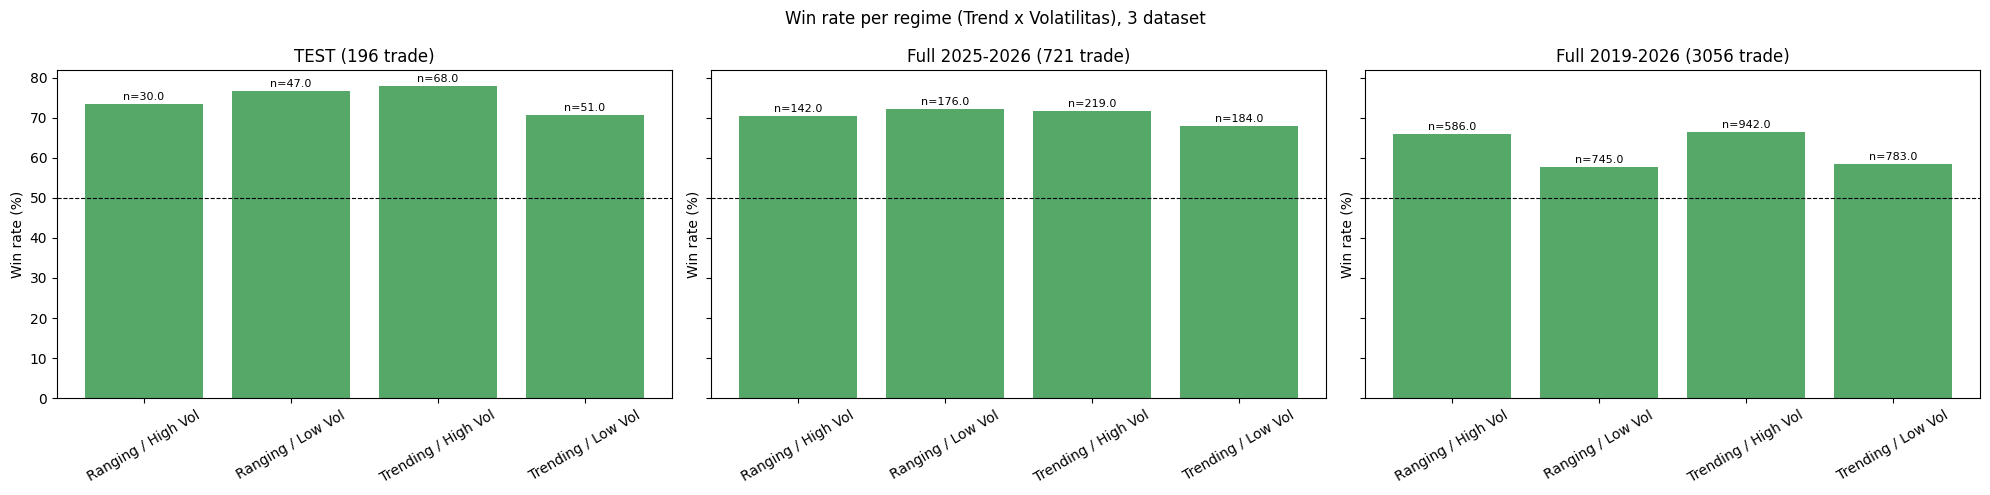

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

for ax, df_r, label in [
    (axes[0], df_test, "TEST (196 trade)"),
    (axes[1], df_full, "Full 2025-2026 (721 trade)"),
    (axes[2], df_1926_trades, "Full 2019-2026 (3056 trade)"),
]:
    perf = regime_performance(df_r, "regime_2x2").sort_index()
    colors = ["#55A868" if wr >= 50 else "#C44E52" for wr in perf["win_rate_pct"]]
    ax.bar(perf.index, perf["win_rate_pct"], color=colors)
    ax.axhline(50, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(label)
    ax.set_ylabel("Win rate (%)")
    ax.tick_params(axis="x", rotation=30)
    for i, (idx, row) in enumerate(perf.iterrows()):
        ax.text(i, row["win_rate_pct"] + 1, f"n={row['n_trades']}", ha="center", fontsize=8)

plt.suptitle("Win rate per regime (Trend x Volatilitas), 3 dataset")
plt.tight_layout()
plt.savefig(EXPORT_DIR / "winrate_by_regime.png", dpi=120)
plt.show()

## 8. Kesimpulan

**Temuan utama — TIDAK ADA regime "bahaya" (rugi), tapi ADA regime yang lebih unggul:**

Beda dari analogi dokter di awal (demam vs hipotermia, dua kondisi ekstrem yang saling
menetralkan), hasil regime labeling v13 justru **konsisten sehat di semua 4 kombinasi regime,
di ketiga dataset** — tidak ada satu pun sel dengan win rate di bawah 50% atau profit factor
di bawah 1. Regime terlemah yang ditemukan (Ranging/Low Vol, dataset 2019-2026 3056 trade):
win rate 57.7%, profit factor 1.95 — masih jelas profitable, cuma kalah dari regime terbaik.

**Ranking konsisten di ketiga dataset (dari yang terkuat ke terlemah):**

| Regime | TEST (196) | Full 2025-26 (721) | Full 2019-26 (3056) |
|---|---|---|---|
| **Trending / High Vol** | WR 77.9%, PF 4.22 | WR 71.7%, PF 4.13 | WR 66.5%, PF 3.19 |
| Ranging / Low Vol | WR 76.6%, PF 3.76 | WR 72.2%, PF 4.81 | WR 57.7%, PF 1.95 |
| Ranging / High Vol | WR 73.3%, PF 2.65 | WR 70.4%, PF 3.04 | WR 65.9%, PF 2.52 |
| Trending / Low Vol | WR 70.6%, PF 2.97 | WR 67.9%, PF 2.88 | WR 58.4%, PF 2.06 |

**Trending/High Vol paling konsisten kuat** di 2 dari 3 dataset (TEST & 2019-2026), dan dekat
puncak di full 2025-2026 juga. Pola yang JELAS & konsisten di ketiga dataset: **High
Vol selalu mengalahkan Low Vol** (baik dalam kondisi Trending maupun Ranging) — volatilitas
tinggi tampaknya lebih penting utk performa v13 drpd arah trend semata.

**Breakdown kuartil ADX** (lebih halus dari split biner 25): pola TIDAK monoton naik seiring
ADX makin tinggi — Q1 (ADX terendah, tapi masih di atas hard filter 18) justru sering kuat
(profit factor tertinggi di TEST: 10.48, & di full 2025-2026: 7.22), sementara Q2 (ADX
menengah-rendah) konsisten JADI YANG TERLEMAH di ketiga dataset (PF 1.62-1.90). Q4 (ADX
tertinggi) TIDAK selalu terbaik — kadang malah lebih lemah dari Q1/Q3, sejalan dgn temuan v13
soal momentum chain exhaustion (ADX ekstrem tinggi ≈ trend sudah matang/rawan reversal, mirip
prinsip yang sama dgn momentum chain 8/8).

**Investigasi tren win rate 52.6%→74.0% (2019→2026): KEDUANYA benar, bukan cuma satu penyebab.**

1. **Komposisi regime BERUBAH DRASTIS**, terutama di 2026: dari campuran cukup merata (2019:
   45.6% Trending/Low-Vol dominan) jadi didominasi Trending/High-Vol & Ranging/High-Vol (2026:
   94% trade ada di kategori High Vol, cuma 5.9% di Low Vol) — market 2026 jauh lebih
   volatile scr konsisten, otomatis lebih banyak trade jatuh di regime yang lebih kuat.
2. **TAPI win rate juga naik DALAM regime yang SAMA** — Ranging: 49.2% (2019) → 76.4% (2026);
   Trending: 54.5% (2019) → 72.3% (2026). Kalau cuma soal komposisi regime, angka DALAM
   kategori yang sama harusnya stabil, bukan naik juga.

**Kesimpulan gabungan**: sebagian tren win rate naik itu karena market 2025-2026 kebetulan lebih
sering menghasilkan kondisi favorit strategi (volatilitas tinggi), TAPI ada juga komponen
independen — performa DALAM regime yang sama pun konsisten membaik seiring waktu. Ini
kemungkinan mencerminkan XAUUSD di rezim harga lebih tinggi ($4300+ vs $1300) menghasilkan
pergerakan absolut (dalam dolar) yang lebih besar per unit ATR, membuat sinyal SL/TP ATR-relatif
v13 "bekerja lebih baik" secara struktural — bukan sekadar soal regime trending/ranging.

**Rekomendasi (bukan keputusan otomatis):**
- **Tidak ada regime yang perlu di-skip** — semua kombinasi tetap profitable, jadi filter
  regime tambahan ("skip kalau Ranging/Low-Vol") TIDAK diperlukan berdasarkan data ini; itu
  akan membuang ~24-44% trade yang tetap menguntungkan (PF>1.9 di semua dataset).
- **High Vol secara konsisten unggul dari Low Vol** — kalau mau eksperimen lanjutan, filter
  tambahan berbasis ATR% minimum yang LEBIH TINGGI dari `atr_min_pct=0.03` saat ini bisa
  dipertimbangkan (saat ini threshold-nya cuma exclude ATR SANGAT rendah, belum
  membedakan "cukup" vs "tinggi") — TAPI ini riset terpisah, TIDAK diterapkan dari v16 ini.
- **Pola ADX non-monoton** (Q2 konsisten terlemah, bukan Q1) mengonfirmasi filter
  `adx_min=18` saat ini SUDAH cukup baik menyaring kondisi ranging murni — menaikkan threshold
  ADX minimum lebih tinggi (mis. ke 25) BELUM TENTU membantu krn Q1 (ADX rendah-menengah)
  justru salah satu yang terkuat, bukan terlemah.
- **Tidak ada perubahan `trade_params`/`signal_params` v13 dari v16** — murni analisis
  deskriptif, bukan riset strategi baru.

**Keterbatasan**: split volatilitas pakai median TIAP DATASET (bukan angka absolut sama) —
supaya adil lintas rezim harga berbeda drastis (2019 $1300 vs 2026 $4300+), tapi berarti
"High Vol" di 2019 beda skala absolut dari "High Vol" di 2026. Kuartil ADX & regime 2x2 dihitung
dari trade YANG SUDAH LOLOS semua filter v13 (termasuk `adx_min=18`) — jadi ini bukan gambaran
regime market secara umum, tapi regime DI ANTARA trade yang memang sudah dianggap layak entry.

In [10]:
for df_r, name in [(df_test, "test"), (df_full, "full_2025_2026"), (df_1926_trades, "full_2019_2026")]:
    regime_performance(df_r, "regime_2x2").to_csv(EXPORT_DIR / f"regime_2x2_{name}.csv")
    regime_performance(df_r, "trend_regime").to_csv(EXPORT_DIR / f"trend_regime_{name}.csv")
    regime_performance(df_r, "vol_regime").to_csv(EXPORT_DIR / f"vol_regime_{name}.csv")

composition.to_csv(EXPORT_DIR / "regime_composition_by_year.csv")
pivot_wr.to_csv(EXPORT_DIR / "winrate_by_year_and_trend.csv")

with open(EXPORT_DIR / "metrics.txt", "w") as f:
    f.write("Regime Labeling v16 -- performa v13 per kondisi market (ADX trend x ATR% volatility)\n\n")
    f.write(f"TREND_ADX_THRESHOLD={TREND_ADX_THRESHOLD} (ADX>=25 Trending, <25 Ranging)\n")
    f.write("Volatility split di median ATR% tiap dataset (bukan angka absolut tetap)\n\n")
    for df_r, name in [(df_test, "TEST (196 trade)"), (df_full, "Full 2025-2026 (721 trade)"), (df_1926_trades, "Full 2019-2026 (3056 trade)")]:
        f.write(f"=== {name} ===\n")
        f.write("-- trend_regime --\n")
        f.write(regime_performance(df_r, "trend_regime").to_string())
        f.write("\n-- vol_regime --\n")
        f.write(regime_performance(df_r, "vol_regime").to_string())
        f.write("\n-- regime_2x2 --\n")
        f.write(regime_performance(df_r, "regime_2x2").to_string())
        f.write("\n\n")
    f.write("=== Komposisi regime per tahun (2019-2026) ===\n")
    f.write(composition.round(1).to_string())
    f.write("\n\n=== Win rate per tahun x trend_regime ===\n")
    f.write(pivot_wr.to_string())

print("Tersimpan ke:", EXPORT_DIR)
for f in sorted(EXPORT_DIR.glob("*")):
    print(" -", f.name)

Tersimpan ke: D:\Projects\robot-scalping\dataset\exports\m5_scalping\v16
 - metrics.txt
 - regime_2x2_full_2019_2026.csv
 - regime_2x2_full_2025_2026.csv
 - regime_2x2_test.csv
 - regime_composition_by_year.csv
 - trend_regime_full_2019_2026.csv
 - trend_regime_full_2025_2026.csv
 - trend_regime_test.csv
 - vol_regime_full_2019_2026.csv
 - vol_regime_full_2025_2026.csv
 - vol_regime_test.csv
 - winrate_by_regime.png
 - winrate_by_year_and_trend.csv
